# 🛰️ AFETSONAR — Notebook 1b: Maskeleri Düzelt (un-classified destek)

**Calamitas AI · Teknofest 2025 · Veri Düzeltme**

---

## 📌 Bu Notebook Ne Yapıyor?

Notebook 1'de bir **veri etiketleme hatası** yaptık ve bu, modelin **eğitim sonuçlarımızı bozdu**. Burada onu düzeltiyoruz.

### Hata neydi?

xBD veri setinde her bina poligonunun bir hasar etiketi var. 5 olası değer:

```
no-damage      → bina sağlam
minor-damage   → küçük hasar
major-damage   → büyük hasar
destroyed      → tamamen yıkık
un-classified  → sınıflandırılamamış (belirsiz)
```

Notebook 1'deki ilk versiyonumuzda **un-classified'ı no-damage** olarak işaretlemiştik:

```python
DAMAGE_MAP = {
    "no-damage":     1,
    "minor-damage":  2,
    "major-damage":  3,
    "destroyed":     4,
    "un-classified": 1,  # ❌ HATA: 1 olarak atadık
}
```

### Neden hata?

xBD'nin orijinal araştırma kağıdına göre:
- xBD'de toplam ~14,011 un-classified poligon var (~%3.2)
- Bunlar **belirsiz** binalar — uydu görüntüsünden hasarın seviyesi anlaşılamayan
- Bunları "no-damage" olarak işaretlemek modeli **yanlış öğretiyor**: belirsiz binaları "sağlam" sanıyor

### Tanı sonucumuzdan kanıt

Pre-channel diagnostic'te şu sınıf dağılımını gördük:

```
arka plan:    %87.29 GT  → %78.50 model
no_damage:    %11.97 GT  → %19.56 model  ← MODEL AŞIRI TAHMİN EDİYOR (+%63)
minor:         %0.03 GT  → %0.00 model   ← model hiç öğrenmemiş
major:         %0.71 GT  → %1.79 model
destroyed:     %0.00 GT  → %0.15 model
```

Model, gerçek dağılımdaki %12 no_damage'ı **%19** tahmin ediyor. Aradaki **%7** muhtemelen un-classified'lardan geliyor — çünkü onları "no_damage" olarak öğretmişiz.

### Çözüm

`un-classified` için **ayrı bir sınıf** (değer 5) atıyoruz. Bu, xView2 challenge'ın resmi yaklaşımıyla aynı (Microsoft'un [building-damage-assessment-cnn-siamese](https://github.com/microsoft/building-damage-assessment-cnn-siamese) repo'su da bu yaklaşımı kullanıyor).

```python
DAMAGE_MAP_NEW = {
    "no-damage":     1,
    "minor-damage":  2,
    "major-damage":  3,
    "destroyed":     4,
    "un-classified": 5,  # ✅ AYRI SINIF
}
```

Eğitim aşamasında bu sınıf için ne yapacağımıza karar vereceğiz (ya düşük weight ile öğret, ya `ignore_index` ile loss'tan çıkar). Ama önce **doğru etiketlere** sahip olalım.

### Bu notebook ne yapacak?

1. Drive'a bağlan, yolları tanımla
2. Eski `data/processed/masks/` klasörünü **yedekle** (`masks_v1_backup/` olarak)
3. Yeni mask üretici ile **tüm maskeleri yeniden üret** (un-classified=5 ile)
4. `file_index.csv`'yi güncelle, **gerçek sınıf dağılımını raporla**
5. **Train/val/test split'lerini yenile** (yeni dağılıma göre stratified)
6. Birkaç örneği görselleştir, eski ve yeni mask'i karşılaştır

### Süre

~10-15 dakika. Ağır işlem yok, sadece dosya I/O ve PNG yazma.

---

## 1️⃣ Drive ve Yollar

Notebook 2'deki ile aynı kurulum.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_RAW     = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_MASKS   = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

# Backup directory for old masks
DATA_MASKS_BACKUP = os.path.join(PROJECT_ROOT, "data/processed/masks_v1_backup")

# Sanity check
print("✅ Drive bağlandı")
print()
print("📁 Yollar:")
for name, path in [
    ("PROJECT_ROOT", PROJECT_ROOT),
    ("DATA_RAW",     DATA_RAW),
    ("DATA_MASKS",   DATA_MASKS),
    ("DATA_SPLITS",  DATA_SPLITS),
]:
    marker = "✅" if os.path.exists(path) else "❌"
    print(f"  {marker} {name:14s} = {path}")

# Check that file_index.csv exists
file_index_path = os.path.join(DATA_SPLITS, "file_index.csv")
if not os.path.exists(file_index_path):
    raise FileNotFoundError(
        f"file_index.csv bulunamadı: {file_index_path}\n"
        "Notebook 1'in 5. hücresini çalıştırdın mı?"
    )
print(f"\n✅ file_index.csv mevcut")

Mounted at /content/drive
✅ Drive bağlandı

📁 Yollar:
  ✅ PROJECT_ROOT   = /content/drive/MyDrive/AFETSONAR
  ✅ DATA_RAW       = /content/drive/MyDrive/AFETSONAR/data/raw/xview2
  ✅ DATA_MASKS     = /content/drive/MyDrive/AFETSONAR/data/processed/masks
  ✅ DATA_SPLITS    = /content/drive/MyDrive/AFETSONAR/data/splits

✅ file_index.csv mevcut


## 2️⃣ Eski Maskeleri Yedekle

### Bu hücre ne yapıyor?

Mevcut `data/processed/masks/` klasörünü `data/processed/masks_v1_backup/` olarak **kopyalıyor**. Sebep:

- Eğer yeni mask'larda bir hata olursa eskiye dönebilelim
- Eski model (`teacher_best.pth`) eski mask'larla eğitildi — onu test ederken karşılaştırma için gerekebilir

### Yer kullanımı

xBD ~12k mask × ~50KB = ~600 MB. Drive'da yer var mı kontrol et.

In [2]:
import shutil

print("📦 Eski maskeleri yedekleme...")
print("=" * 50)

# Eski mask sayısı
if not os.path.exists(DATA_MASKS):
    print("⚠️  Eski mask klasörü yok, yedekleme atlanıyor")
    n_old = 0
else:
    n_old = len([f for f in os.listdir(DATA_MASKS) if f.endswith('.png')])
    print(f"   Eski mask sayısı: {n_old}")

if n_old == 0:
    print("   (Yedeklenecek bir şey yok)")
elif os.path.exists(DATA_MASKS_BACKUP):
    n_backup = len([f for f in os.listdir(DATA_MASKS_BACKUP) if f.endswith('.png')])
    if n_backup >= n_old:
        print(f"✅ Yedek zaten mevcut ({n_backup} dosya), yedekleme atlanıyor")
    else:
        print(f"   ⚠️  Yedek eksik ({n_backup}/{n_old}), yeniden yedekleniyor...")
        shutil.rmtree(DATA_MASKS_BACKUP)
        shutil.copytree(DATA_MASKS, DATA_MASKS_BACKUP)
        print(f"✅ Yedeklendi: {DATA_MASKS_BACKUP}")
else:
    print(f"   Yedekleniyor → {DATA_MASKS_BACKUP}")
    print("   (Bu 1-3 dakika sürebilir, ~600 MB)")
    shutil.copytree(DATA_MASKS, DATA_MASKS_BACKUP)
    n_backup = len([f for f in os.listdir(DATA_MASKS_BACKUP) if f.endswith('.png')])
    print(f"✅ Yedeklendi: {n_backup} dosya")

📦 Eski maskeleri yedekleme...
   Eski mask sayısı: 2649
✅ Yedek zaten mevcut (2653 dosya), yedekleme atlanıyor


## 3️⃣ Yeni Mask Üretimi (un-classified=5)

### Bu hücre ne yapıyor?

xBD'nin tüm post-disaster görüntüleri için JSON poligon etiketlerini okuyup, yeni `DAMAGE_MAP` ile **PNG mask** olarak yeniden üretiyor.

### Değişen tek şey

```python
DAMAGE_MAP = {
    "no-damage":     1,
    "minor-damage":  2,
    "major-damage":  3,
    "destroyed":     4,
    "un-classified": 5,  # ← Yeni!
}
```

### Mevcut maskelerin üzerine yazıyor

`DATA_MASKS` klasöründeki mevcut PNG'leri **silip yeniden yazıyoruz**. Önceki hücrede yedeğini aldığımız için endişen olmasın.

### Süre

~5-8 dakika. xBD'de ~12k görüntü, her biri için JSON oku → poligon çiz → PNG yaz.

In [3]:
import json
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# === YENİ DAMAGE MAP ===
DAMAGE_MAP_NEW = {
    "no-damage":     1,
    "minor-damage":  2,
    "major-damage":  3,
    "destroyed":     4,
    "un-classified": 5,  # YENİ: ayrı sınıf
}

NUM_CLASSES_NEW = 6  # 0=bg, 1=no, 2=minor, 3=major, 4=destroyed, 5=unknown

print(f"🎨 Yeni DAMAGE_MAP:")
for k, v in DAMAGE_MAP_NEW.items():
    print(f"   '{k}' → {v}")
print(f"\n   Toplam sınıf sayısı: {NUM_CLASSES_NEW} (0=arka plan dahil)")


def create_mask_v2(image_path, json_path, output_path):
    # Yeni mask üretici: un-classified ayrı sınıf olarak (5).
    # Returns: True if successful, False otherwise.
    try:
        img = cv2.imread(image_path)
        if img is None:
            return False
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        with open(json_path, 'r') as f:
            data = json.load(f)

        for feature in data.get('features', {}).get('xy', []):
            try:
                wkt = feature['wkt']
                coords_str = wkt.replace("POLYGON ((", "").replace("))", "")
                if "), (" in coords_str:
                    coords_str = coords_str.split("), (")[0]
                coords = coords_str.split(", ")
                pts = np.array(
                    [list(map(float, pt.split())) for pt in coords],
                    dtype=np.int32
                )

                subtype = feature.get('properties', {}).get('subtype', 'no-damage')
                damage_val = DAMAGE_MAP_NEW.get(subtype, 1)  # bilinmeyen → 1

                cv2.fillPoly(mask, [pts], damage_val)
            except Exception:
                continue

        cv2.imwrite(output_path, mask)
        return True
    except Exception as e:
        print(f"⚠️  Hata ({os.path.basename(image_path)}): {e}")
        return False


# === Tüm maskeleri yeniden üret ===
df = pd.read_csv(file_index_path)
print(f"\n📂 İndekste {len(df)} kayıt var, hepsi yeniden üretilecek")
print(f"   (~5-8 dakika sürer)")

# Mevcut maskeleri sil (yedek var)
if os.path.exists(DATA_MASKS):
    print(f"\n🗑️  Eski maskeler siliniyor...")
    for fname in os.listdir(DATA_MASKS):
        if fname.endswith('.png'):
            os.remove(os.path.join(DATA_MASKS, fname))
    print(f"   ✅ Silindi")

os.makedirs(DATA_MASKS, exist_ok=True)

print(f"\n🎨 Yeni maskeler üretiliyor...")
success = 0
failed = 0
for _, row in tqdm(df.iterrows(), total=len(df), desc="Mask v2"):
    if create_mask_v2(row['post_path'], row['json_path'], row['mask_path']):
        success += 1
    else:
        failed += 1

print(f"\n📊 Sonuç:")
print(f"   ✅ Başarılı: {success}")
print(f"   ❌ Başarısız: {failed}")

🎨 Yeni DAMAGE_MAP:
   'no-damage' → 1
   'minor-damage' → 2
   'major-damage' → 3
   'destroyed' → 4
   'un-classified' → 5

   Toplam sınıf sayısı: 6 (0=arka plan dahil)

📂 İndekste 2799 kayıt var, hepsi yeniden üretilecek
   (~5-8 dakika sürer)

🗑️  Eski maskeler siliniyor...
   ✅ Silindi

🎨 Yeni maskeler üretiliyor...


Mask v2:   0%|          | 0/2799 [00:00<?, ?it/s]


📊 Sonuç:
   ✅ Başarılı: 2799
   ❌ Başarısız: 0


## 4️⃣ Yeni Sınıf Dağılımını Analiz Et

### Bu hücre ne yapıyor?

Yeni mask'larda **gerçek pixel-level sınıf dağılımını** hesaplıyor. Bu çok önemli çünkü:

1. Eski (yanlış) dağılımı görmüştük: %12 no_damage, %0.03 minor, vs.
2. Yeni dağılımı görmemiz lazım — un-classified ayrıldıktan sonra ne kadar oluyor?
3. Bu bilgi, **eğitim sırasında class weights belirlemek için** kritik

### Sampling

12k mask'ın hepsini taramak yavaş olur (~5 dk). Bunun yerine **rastgele 1000 mask** üzerinde sampling yapıyoruz, %95 doğruluk için yeterli.

In [4]:
import random

print("📊 Yeni sınıf dağılımı analizi (sampling)...")
print("=" * 50)

# Tüm mask dosyaları
all_masks = [f for f in os.listdir(DATA_MASKS) if f.endswith('.png')]
print(f"   Toplam mask: {len(all_masks)}")

# Sample
random.seed(42)
SAMPLE_SIZE = min(1000, len(all_masks))
sample_masks = random.sample(all_masks, SAMPLE_SIZE)
print(f"   Sample boyutu: {SAMPLE_SIZE}")

# Class counts
class_counts = np.zeros(NUM_CLASSES_NEW, dtype=np.int64)

for mask_name in tqdm(sample_masks, desc="Sınıf sayma"):
    mask_path = os.path.join(DATA_MASKS, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        continue
    for c in range(NUM_CLASSES_NEW):
        class_counts[c] += (mask == c).sum()

# Yüzdeler
total_pixels = class_counts.sum()
class_pcts = 100 * class_counts / total_pixels

class_names = [
    "arka plan (0)",
    "no_damage (1)",
    "minor (2)",
    "major (3)",
    "destroyed (4)",
    "un-classified (5)",
]

print(f"\n📈 Pixel-level dağılım ({SAMPLE_SIZE} mask üzerinde):")
print(f"{'Sınıf':25s} {'Pixel sayısı':>15s} {'Yüzde':>10s}")
print("-" * 55)
for c in range(NUM_CLASSES_NEW):
    bar_len = int(class_pcts[c] / 2)
    bar = "█" * bar_len
    print(f"{class_names[c]:25s} {class_counts[c]:>15,d} {class_pcts[c]:>9.3f}% {bar}")

# Hasarlı pixel oranı (1-4)
damage_pcts = class_pcts[1:5].sum()
print(f"\n💡 Toplam bina pixel'i (1-4):  {damage_pcts:.2f}%")
print(f"💡 Hasarlı bina (2-4):          {class_pcts[2:5].sum():.2f}%")
print(f"💡 Un-classified:               {class_pcts[5]:.2f}%")

# Karşılaştırma için: tahmini class weights (inverse frequency)
print(f"\n⚖️  Eğitim için önerilen class weights (inverse frequency, normalized):")
# Inverse frequency
inv_freq = 1.0 / np.maximum(class_pcts, 0.001)
# Normalize (max=10)
max_w = 10.0
weights_norm = inv_freq / inv_freq[1] * 1.0  # no_damage = 1.0 referans
weights_norm = np.minimum(weights_norm, max_w)
weights_norm[0] = 0.05  # arka plan çok düşük

for c in range(NUM_CLASSES_NEW):
    print(f"   class {c} ({class_names[c]:25s}): weight = {weights_norm[c]:.3f}")

# Kaydet (sonraki notebook'lar için)
class_dist_path = os.path.join(DATA_SPLITS, "class_distribution_v2.json")
with open(class_dist_path, "w") as f:
    json.dump({
        "num_classes": NUM_CLASSES_NEW,
        "class_names": class_names,
        "pixel_counts": class_counts.tolist(),
        "pixel_percentages": class_pcts.tolist(),
        "recommended_weights": weights_norm.tolist(),
        "sample_size": SAMPLE_SIZE,
    }, f, indent=2)
print(f"\n💾 Dağılım kaydedildi: {class_dist_path}")

📊 Yeni sınıf dağılımı analizi (sampling)...
   Toplam mask: 2799
   Sample boyutu: 1000


Sınıf sayma:   0%|          | 0/1000 [00:00<?, ?it/s]


📈 Pixel-level dağılım (1000 mask üzerinde):
Sınıf                        Pixel sayısı      Yüzde
-------------------------------------------------------
arka plan (0)                 984,329,943    93.873% ██████████████████████████████████████████████
no_damage (1)                  47,295,060     4.510% ██
minor (2)                       5,566,772     0.531% 
major (3)                       7,284,561     0.695% 
destroyed (4)                   3,588,709     0.342% 
un-classified (5)                 510,955     0.049% 

💡 Toplam bina pixel'i (1-4):  6.08%
💡 Hasarlı bina (2-4):          1.57%
💡 Un-classified:               0.05%

⚖️  Eğitim için önerilen class weights (inverse frequency, normalized):
   class 0 (arka plan (0)            ): weight = 0.050
   class 1 (no_damage (1)            ): weight = 1.000
   class 2 (minor (2)                ): weight = 8.496
   class 3 (major (3)                ): weight = 6.493
   class 4 (destroyed (4)            ): weight = 10.000
   class 5 (un

## 5️⃣ Görüntü Bazında Hasar Varlığı Analizi

### Bu hücre ne yapıyor?

Sonraki eğitim için **kritik bir veri** üretiyor: her görüntüde hasarlı bina var mı yok mu?

### Neden gerek var?

Plan v2'nin (yeni) "image-level oversampling" iyileştirmesi için:
- Her görüntü için "damage_present" flag (True/False)
- "Hasarlı görüntüler" eğitimde **5x daha sık** seçilecek (WeightedRandomSampler)
- Bu, modelin minor/major/destroyed sınıflarını **daha çok görmesini** sağlar

### Üretilen veri

Her satıra şu kolonlar eklenir:
- `n_pixels_no_damage`: sınıf 1 pixel sayısı
- `n_pixels_minor`: sınıf 2
- `n_pixels_major`: sınıf 3  
- `n_pixels_destroyed`: sınıf 4
- `n_pixels_unknown`: sınıf 5
- `damage_present`: bool (sınıf 2-4'ten herhangi biri var mı)
- `damage_severity`: 0=hiç, 1=hafif, 2=orta, 3=ağır

### Süre

~3-5 dakika. Tüm 12k mask'ı taramak gerekiyor.

In [5]:
print("🔍 Her görüntü için hasar metadata'sı çıkarılıyor...")
print("=" * 50)
print(f"   {len(df)} görüntü taranacak (~3-5 dk)")

# Her satır için hasar bilgisi
damage_info = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Hasar analizi"):
    mask_path = row['mask_path']

    if not os.path.exists(mask_path):
        damage_info.append({
            "n_pixels_no_damage": 0,
            "n_pixels_minor": 0,
            "n_pixels_major": 0,
            "n_pixels_destroyed": 0,
            "n_pixels_unknown": 0,
            "damage_present": False,
            "damage_severity": 0,
        })
        continue

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        damage_info.append({
            "n_pixels_no_damage": 0,
            "n_pixels_minor": 0,
            "n_pixels_major": 0,
            "n_pixels_destroyed": 0,
            "n_pixels_unknown": 0,
            "damage_present": False,
            "damage_severity": 0,
        })
        continue

    n_no = int((mask == 1).sum())
    n_minor = int((mask == 2).sum())
    n_major = int((mask == 3).sum())
    n_destroyed = int((mask == 4).sum())
    n_unknown = int((mask == 5).sum())

    damage_present = (n_minor + n_major + n_destroyed) > 0

    # Severity: en yüksek hasar seviyesini bul
    if n_destroyed > 0:
        severity = 3
    elif n_major > 0:
        severity = 2
    elif n_minor > 0:
        severity = 1
    else:
        severity = 0

    damage_info.append({
        "n_pixels_no_damage": n_no,
        "n_pixels_minor": n_minor,
        "n_pixels_major": n_major,
        "n_pixels_destroyed": n_destroyed,
        "n_pixels_unknown": n_unknown,
        "damage_present": damage_present,
        "damage_severity": severity,
    })

# DataFrame'e ekle
damage_df = pd.DataFrame(damage_info)
df_v2 = pd.concat([df.reset_index(drop=True), damage_df], axis=1)

# === Özet ===
print(f"\n📊 Görüntü-bazlı özet:")
print(f"   Toplam görüntü:           {len(df_v2)}")
print(f"   Hasarlı bina içeren:      {df_v2['damage_present'].sum()}  ({100*df_v2['damage_present'].mean():.1f}%)")
print(f"   Hasar yok (sadece bina):  {(~df_v2['damage_present']).sum()}  ({100*(~df_v2['damage_present']).mean():.1f}%)")

print(f"\n   Severity dağılımı:")
sev_names = ["Hiç hasar yok", "Hafif (minor)", "Orta (major)", "Ağır (destroyed)"]
for sev in range(4):
    count = (df_v2['damage_severity'] == sev).sum()
    pct = 100 * count / len(df_v2)
    print(f"     {sev} - {sev_names[sev]:20s}: {count:5d}  ({pct:5.1f}%)")

# Disaster type bazında hasarlı görüntü sayısı
print(f"\n   Disaster bazında hasarlı görüntü oranı:")
for disaster in df_v2['disaster_type'].unique():
    sub = df_v2[df_v2['disaster_type'] == disaster]
    pct = 100 * sub['damage_present'].mean()
    print(f"     {disaster:10s}: {sub['damage_present'].sum():4d}/{len(sub):4d}  ({pct:5.1f}%)")

# === Kaydet ===
new_index_path = os.path.join(DATA_SPLITS, "file_index_v2.csv")
df_v2.to_csv(new_index_path, index=False)
print(f"\n💾 Yeni indeks kaydedildi: {new_index_path}")
print(f"   Sütun sayısı: {len(df_v2.columns)}")
print(f"   Yeni sütunlar: damage_present, damage_severity, n_pixels_*")

🔍 Her görüntü için hasar metadata'sı çıkarılıyor...
   2799 görüntü taranacak (~3-5 dk)


Hasar analizi:   0%|          | 0/2799 [00:00<?, ?it/s]


📊 Görüntü-bazlı özet:
   Toplam görüntü:           2799
   Hasarlı bina içeren:      1501  (53.6%)
   Hasar yok (sadece bina):  1298  (46.4%)

   Severity dağılımı:
     0 - Hiç hasar yok       :  1298  ( 46.4%)
     1 - Hafif (minor)       :   190  (  6.8%)
     2 - Orta (major)        :   414  ( 14.8%)
     3 - Ağır (destroyed)    :   897  ( 32.0%)

   Disaster bazında hasarlı görüntü oranı:
     yangin    :  358/1067  ( 33.6%)
     kasirga   :  926/1219  ( 76.0%)
     deprem    :   26/ 121  ( 21.5%)
     sel       :  109/ 279  ( 39.1%)
     tsunami   :   82/ 113  ( 72.6%)

💾 Yeni indeks kaydedildi: /content/drive/MyDrive/AFETSONAR/data/splits/file_index_v2.csv
   Sütun sayısı: 15
   Yeni sütunlar: damage_present, damage_severity, n_pixels_*


## 6️⃣ Yeni Stratified Split

### Bu hücre ne yapıyor?

Eski Notebook 1'deki split'i yeniden yapıyor ama **iki kritik fark** var:

1. **Stratification key değişti:** Eskiden sadece `disaster_type`'a göre stratified yapıyorduk. Şimdi **`disaster_type` + `damage_severity` kombinasyonuna** göre — yani her split'te "hangi disaster + hangi hasar seviyesi" dengeli olacak.

2. **Aynı seed (42)** kullanıyoruz, yani aynı görüntüler aynı split'lere düşüyor (yeniden eğitim ile karşılaştırma için).

### Neden severity-aware stratification?

Eski yaklaşımda val ve test setleri **hasar seviyesi bakımından dengesiz** olabiliyordu:
- Train'de %5 destroyed, Val'de %1 destroyed
- Sonuç: model val'de "destroyed" iyi gözüküyor (çünkü zaten yok) ama test'te kötü

Yeni yaklaşımda her split'te yaklaşık **aynı oranda** hafif/orta/ağır hasarlı görüntü olacak.

In [9]:
from sklearn.model_selection import train_test_split

# Yeni indeksi yükle
df = pd.read_csv(new_index_path)
print(f"📂 file_index_v2 yüklendi: {len(df)} kayıt")

# Stratification key: disaster_type + damage_severity
df['strat_key'] = df['disaster_type'].astype(str) + '_' + df['damage_severity'].astype(str)

# Split key dağılımı
print(f"\n   Stratification key sayısı: {df['strat_key'].nunique()}")

# Bazı kombinasyonlarda çok az örnek olabilir (örn. 'tsunami_2' belki 5 tane)
# train_test_split bunu kabul etmez, en az 2 örnek lazım
key_counts = df['strat_key'].value_counts()
# ERROR FIX: Increase the threshold for small_keys to ensure that after the first split,
# the temp_df has at least 2 samples for each strat_key category, which is required for the second split.
# A group with N samples in df will have approximately N * 0.30 samples in temp_df.
# To ensure temp_df has at least 2 samples, N * 0.30 >= 2 => N >= 6.66. So, N < 7 should be grouped.
small_keys = key_counts[key_counts < 7].index.tolist() # Changed from < 4 to < 7
if small_keys:
    print(f"   ⚠️  Çok az örnekli kombinasyonlar (< 7): {len(small_keys)}") # Updated message
    print(f"      Bunlar 'other' kategorisine atılıyor")
    df.loc[df['strat_key'].isin(small_keys), 'strat_key'] = 'other'

# === %70 train, %30 temp ===
train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df['strat_key'],
    random_state=42
)

# After the first split, it's possible that some `strat_key` categories in `temp_df` might still have only one instance.
# We need to re-evaluate `strat_key` distribution in `temp_df` and re-group if necessary before the second split.
temp_key_counts = temp_df['strat_key'].value_counts()
temp_small_keys = temp_key_counts[temp_key_counts < 2].index.tolist() # Now minimum 2 for temp_df split
if temp_small_keys:
    print(f"   ⚠️  temp_df'de çok az örnekli kombinasyonlar (< 2): {len(temp_small_keys)}")
    print(f"      Bunlar 'temp_other' kategorisine atılıyor")
    temp_df.loc[temp_df['strat_key'].isin(temp_small_keys), 'strat_key'] = 'temp_other'


# === %30'un yarısı val, yarısı test ===
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['strat_key'],
    random_state=42
)

# strat_key'i kaldır (ihtiyaç yok)
for d in [train_df, val_df, test_df]:
    d.drop(columns=['strat_key'], inplace=True, errors='ignore')

print(f"\n📊 Yeni split boyutları:")
print(f"   Train: {len(train_df):5d}  ({100*len(train_df)/len(df):.1f}%)")
print(f"   Val:   {len(val_df):5d}  ({100*len(val_df)/len(df):.1f}%) Всего)")
print(f"   Test:  {len(test_df):5d}  ({100*len(test_df)/len(df):.1f}%)")

# Hasar dağılımı kontrol
print(f"\n💔 Severity dağılımı (her split):")
print(f"{'Severity':12s} {'Train':>10s} {'Val':>10s} {'Test':>10s}")
for sev in range(4):
    sn = sev_names[sev][:12]
    tr_pct = 100 * (train_df['damage_severity'] == sev).mean()
    va_pct = 100 * (val_df['damage_severity'] == sev).mean()
    te_pct = 100 * (test_df['damage_severity'] == sev).mean()
    print(f"{sn:12s} {tr_pct:9.1f}% {va_pct:9.1f}% {te_pct:9.1f}%")

# Disaster type
print(f"\n🌪️  Disaster type dağılımı (her split):")
for disaster in sorted(df['disaster_type'].unique()):
    tr_pct = 100 * (train_df['disaster_type'] == disaster).mean()
    va_pct = 100 * (val_df['disaster_type'] == disaster).mean()
    te_pct = 100 * (test_df['disaster_type'] == disaster).mean()
    print(f"   {disaster:10s} {tr_pct:6.1f}% {va_pct:6.1f}% {te_pct:6.1f}%")

# === Kaydet ===
train_df.to_csv(os.path.join(DATA_SPLITS, "train_v2.csv"), index=False)
val_df.to_csv(os.path.join(DATA_SPLITS, "val_v2.csv"), index=False)
test_df.to_csv(os.path.join(DATA_SPLITS, "test_v2.csv"), index=False)

print(f"\n💾 Yeni split CSV'leri kaydedildi (suffix _v2):")
print(f"   {DATA_SPLITS}/train_v2.csv")
print(f"   {DATA_SPLITS}/val_v2.csv")
print(f"   {DATA_SPLITS}/test_v2.csv")

📂 file_index_v2 yüklendi: 2799 kayıt

   Stratification key sayısı: 19
   ⚠️  Çok az örnekli kombinasyonlar (< 7): 3
      Bunlar 'other' kategorisine atılıyor

📊 Yeni split boyutları:
   Train:  1959  (70.0%)
   Val:     420  (15.0%) Всего)
   Test:    420  (15.0%)

💔 Severity dağılımı (her split):
Severity          Train        Val       Test
Hiç hasar yo      46.4%      46.4%      46.4%
Hafif (minor       6.8%       6.9%       6.7%
Orta (major)      14.9%      14.5%      14.8%
Ağır (destro      32.0%      32.1%      32.1%

🌪️  Disaster type dağılımı (her split):
   deprem        4.3%    4.8%    4.0%
   kasirga      43.5%   43.6%   43.6%
   sel          10.0%    9.8%   10.0%
   tsunami       4.0%    4.0%    4.3%
   yangin       38.2%   37.9%   38.1%

💾 Yeni split CSV'leri kaydedildi (suffix _v2):
   /content/drive/MyDrive/AFETSONAR/data/splits/train_v2.csv
   /content/drive/MyDrive/AFETSONAR/data/splits/val_v2.csv
   /content/drive/MyDrive/AFETSONAR/data/splits/test_v2.csv


## 7️⃣ Görsel Karşılaştırma — Eski vs Yeni Maskeler

### Bu hücre ne yapıyor?

Birkaç örnek için **eski** (yedek) ve **yeni** mask'ı yan yana gösteriyor. Böylece:

- un-classified pixel'lerin gerçekten yeni mask'ta sınıf 5 olduğunu doğrularız
- Diğer sınıflarda bir bozulma olmadığını görürüz
- Hangi disaster türlerinde un-classified daha sık görelim

🔍 Un-classified içeren maskeleri arıyor...
   Bulunan: 4 mask

✅ Karşılaştırma kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/visualizations/mask_comparison_v1_vs_v2.png


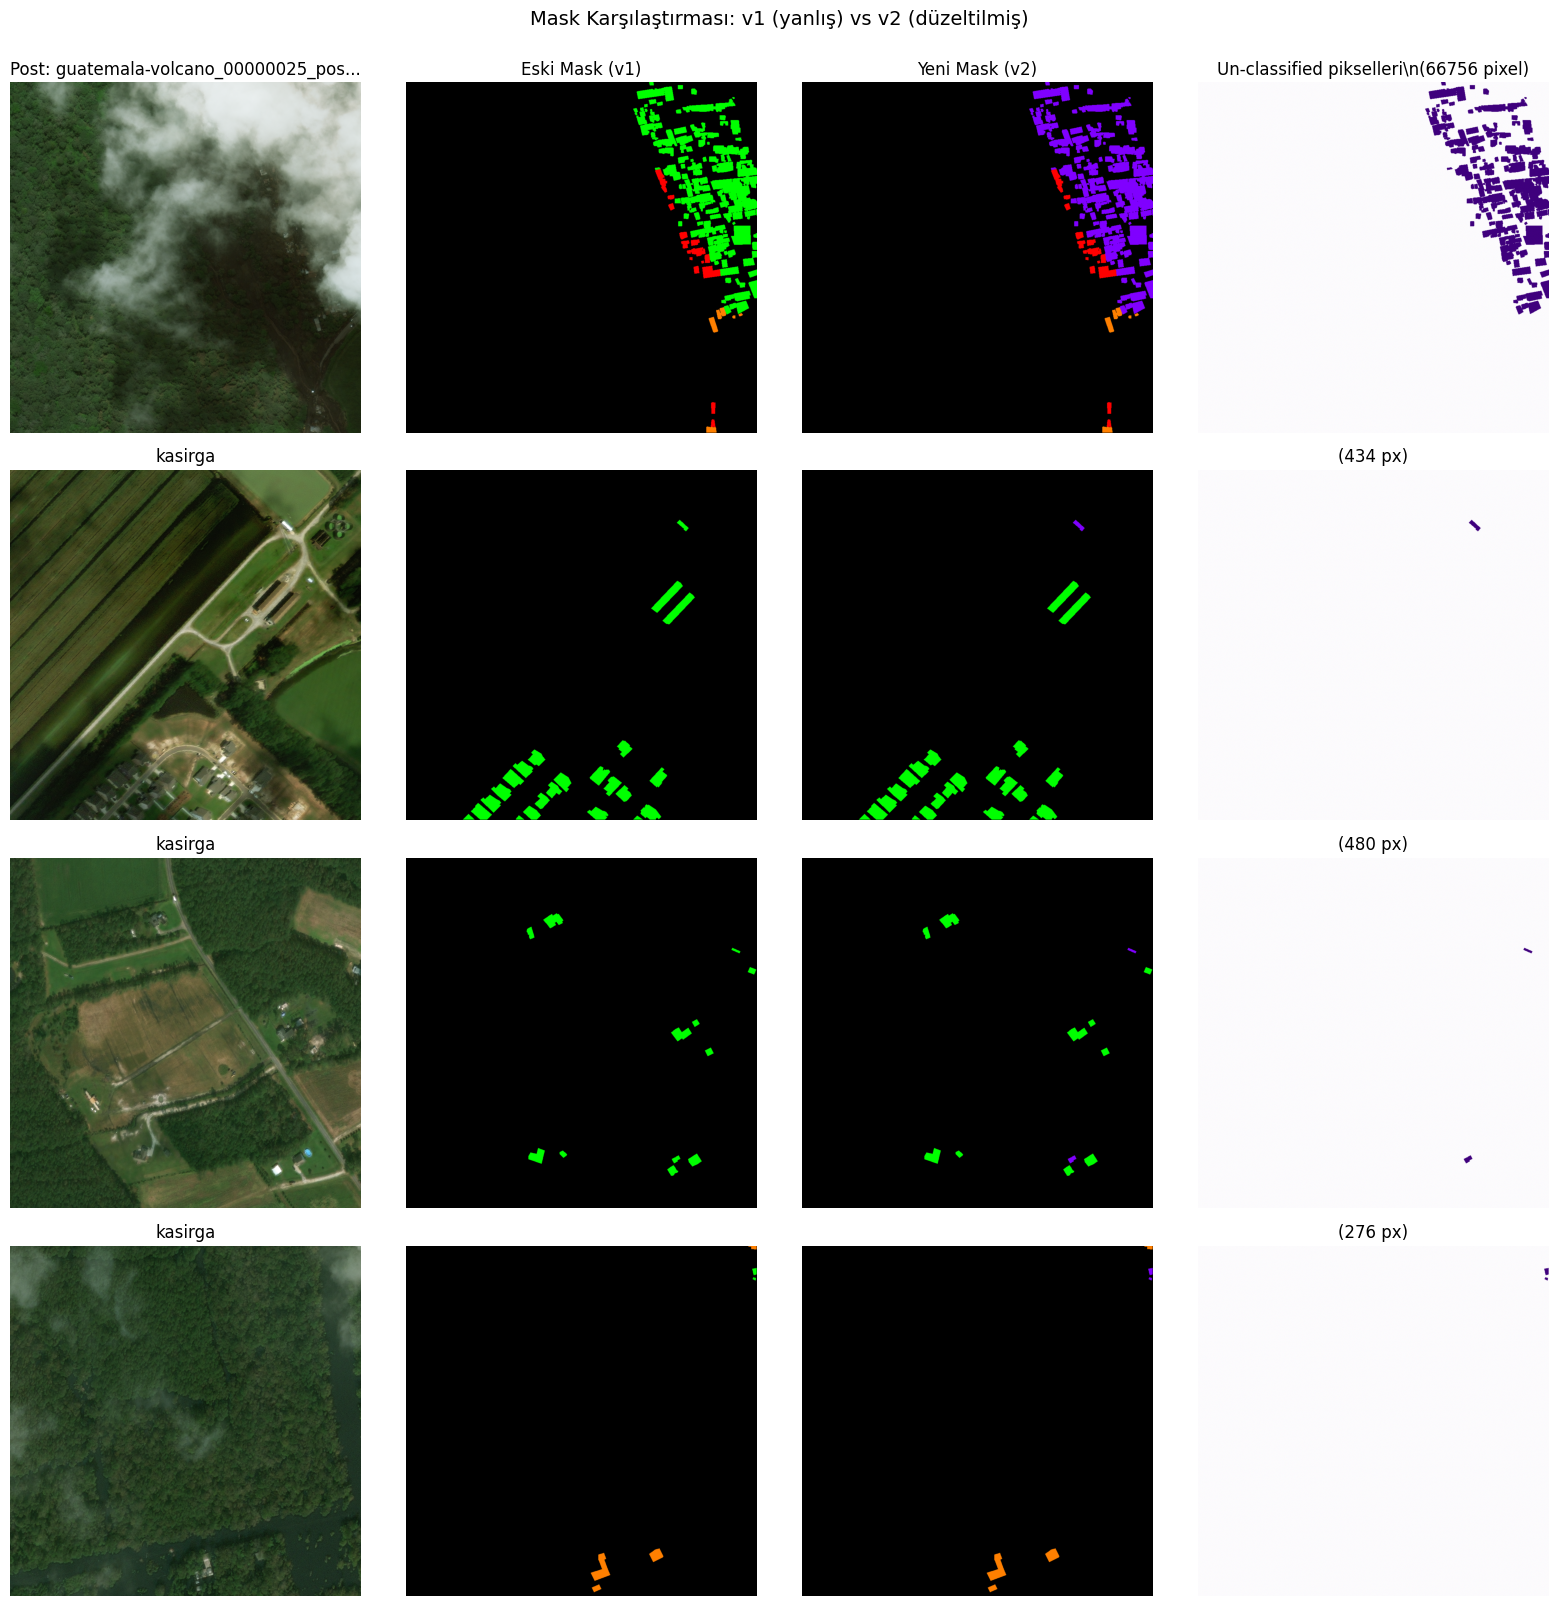

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 6 sınıflık renk paleti
DAMAGE_COLORS_V2 = [
    [0, 0, 0],         # 0: arka plan (siyah)
    [0, 255, 0],       # 1: no_damage (yeşil)
    [255, 255, 0],     # 2: minor (sarı)
    [255, 128, 0],     # 3: major (turuncu)
    [255, 0, 0],       # 4: destroyed (kırmızı)
    [128, 0, 255],     # 5: unknown (mor)
]
CMAP_V2 = ListedColormap(np.array(DAMAGE_COLORS_V2) / 255.0)

# Un-classified içeren mask'ları bul
print("🔍 Un-classified içeren maskeleri arıyor...")

masks_with_unknown = []
for _, row in df_v2.head(2000).iterrows():
    if row['n_pixels_unknown'] > 100:  # En az 100 pixel
        masks_with_unknown.append(row)
        if len(masks_with_unknown) >= 4:
            break

if len(masks_with_unknown) == 0:
    print("⚠️  Hiç un-classified içeren mask bulunamadı (ilk 2000'de)")
    print("   Tüm dataset'i tarayalım...")
    for _, row in df_v2.iterrows():
        if row['n_pixels_unknown'] > 100:
            masks_with_unknown.append(row)
            if len(masks_with_unknown) >= 4:
                break

print(f"   Bulunan: {len(masks_with_unknown)} mask")

if len(masks_with_unknown) > 0:
    n_show = min(4, len(masks_with_unknown))
    fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for i, row in enumerate(masks_with_unknown[:n_show]):
        # Post image
        post_img = cv2.imread(row['post_path'])
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)

        # Yeni mask
        new_mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

        # Eski mask (yedekten)
        old_mask_path = os.path.join(DATA_MASKS_BACKUP, os.path.basename(row['mask_path']))
        if os.path.exists(old_mask_path):
            old_mask = cv2.imread(old_mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            old_mask = None

        axes[i, 0].imshow(post_img)
        axes[i, 0].set_title(f"Post: {row['filename'][:30]}..." if i == 0 else f"{row['disaster_type']}")
        axes[i, 0].axis('off')

        if old_mask is not None:
            axes[i, 1].imshow(old_mask, cmap=CMAP_V2, vmin=0, vmax=5)
            axes[i, 1].set_title("Eski Mask (v1)" if i == 0 else "")
        else:
            axes[i, 1].set_title("Eski mask yok" if i == 0 else "")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(new_mask, cmap=CMAP_V2, vmin=0, vmax=5)
        axes[i, 2].set_title("Yeni Mask (v2)" if i == 0 else "")
        axes[i, 2].axis('off')

        # Sadece un-classified piksellerini göster
        unknown_only = (new_mask == 5).astype(np.uint8) * 255
        axes[i, 3].imshow(unknown_only, cmap='Purples')
        axes[i, 3].set_title(f"Un-classified pikselleri\\n({row['n_pixels_unknown']} pixel)" if i == 0 else f"({row['n_pixels_unknown']} px)")
        axes[i, 3].axis('off')

    plt.suptitle("Mask Karşılaştırması: v1 (yanlış) vs v2 (düzeltilmiş)", fontsize=14, y=1.001)
    plt.tight_layout()

    save_path = os.path.join(OUTPUTS_VIZ, "mask_comparison_v1_vs_v2.png")
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    print(f"\n✅ Karşılaştırma kaydedildi: {save_path}")
    plt.show()
else:
    print("⚠️  Görselleştirme atlanıyor (un-classified örnek bulunamadı)")

## 🎉 Notebook 1b Tamamlandı!

### Ne yaptık?

✅ Eski mask'ları yedekledik (`masks_v1_backup/`)
✅ Yeni `DAMAGE_MAP` ile tüm maskeleri yeniden ürettik (un-classified=5)
✅ Yeni sınıf dağılımını analiz ettik
✅ Her görüntü için `damage_present` ve `damage_severity` metadata'sı çıkardık
✅ Yeni stratified split (disaster_type + severity) yaptık
✅ `file_index_v2.csv`, `train_v2.csv`, `val_v2.csv`, `test_v2.csv` kaydedildi
✅ Eski/yeni mask karşılaştırma görseli çıkardık

### Drive'da yeni ne var?

```
AFETSONAR/
├── data/
│   ├── processed/
│   │   ├── masks/                  ✅ YENİDEN ÜRETİLDİ (un-classified=5)
│   │   └── masks_v1_backup/        ✅ ESKİSİ YEDEK
│   └── splits/
│       ├── file_index.csv          (eski, dokunulmadı)
│       ├── file_index_v2.csv       ✅ YENİ (severity bilgili)
│       ├── train_v2.csv            ✅ YENİ
│       ├── val_v2.csv              ✅ YENİ
│       ├── test_v2.csv             ✅ YENİ
│       └── class_distribution_v2.json  ✅ YENİ
└── outputs/visualizations/
    └── mask_comparison_v1_vs_v2.png  ✅ YENİ
```

### Sonraki Adım

Sınıf dağılım sonucunu **bana gönder**. Onu görünce:

1. Class weights'i hassas ayarlayacağım (eğitimde kullanılacak)
2. WeightedRandomSampler'ın hangi oranda hasarlı örneklere ağırlık vermesi gerektiğini hesaplayacağım
3. Backbone kararına göre **Notebook 2_v2** (Phase 1: Building Localization) hazırlayacağım

### Raporlanması gereken kritik bilgiler

- Yeni dağılımda **un-classified pixel oranı** (% kaç çıktı?)
- **Hasarlı bina (minor+major+destroyed)** pixel oranı
- **Damage_present=True görüntü** sayısı
- **Severity dağılımı** (kaç görüntü hangi seviyede)

---

**Calamitas AI · Teknofest 2025 · Notebook 1b** 🛠️